Parameters: 29,018 / 50,000
Epoch 1: Train Acc=85.87%, Val Acc=95.73%
Epoch 2: Train Acc=96.61%, Val Acc=97.10%
Epoch 3: Train Acc=97.53%, Val Acc=97.71%
Epoch 4: Train Acc=97.95%, Val Acc=98.24%
Epoch 5: Train Acc=98.32%, Val Acc=98.62%
Epoch 6: Train Acc=98.50%, Val Acc=98.52%
Epoch 7: Train Acc=98.74%, Val Acc=98.50%
Epoch 8: Train Acc=98.75%, Val Acc=98.63%
Epoch 9: Train Acc=99.00%, Val Acc=98.68%
Epoch 10: Train Acc=99.04%, Val Acc=98.63%
Epoch 11: Train Acc=99.18%, Val Acc=98.84%
Epoch 12: Train Acc=99.24%, Val Acc=98.91%
Epoch 13: Train Acc=99.18%, Val Acc=98.60%
Epoch 14: Train Acc=99.31%, Val Acc=98.58%
Epoch 15: Train Acc=99.39%, Val Acc=98.73%
Epoch 16: Train Acc=99.47%, Val Acc=98.63%
Epoch 17: Train Acc=99.54%, Val Acc=98.48%
Epoch 18: Train Acc=99.52%, Val Acc=98.78%
Epoch 19: Train Acc=99.61%, Val Acc=99.01%
Epoch 20: Train Acc=99.60%, Val Acc=98.70%


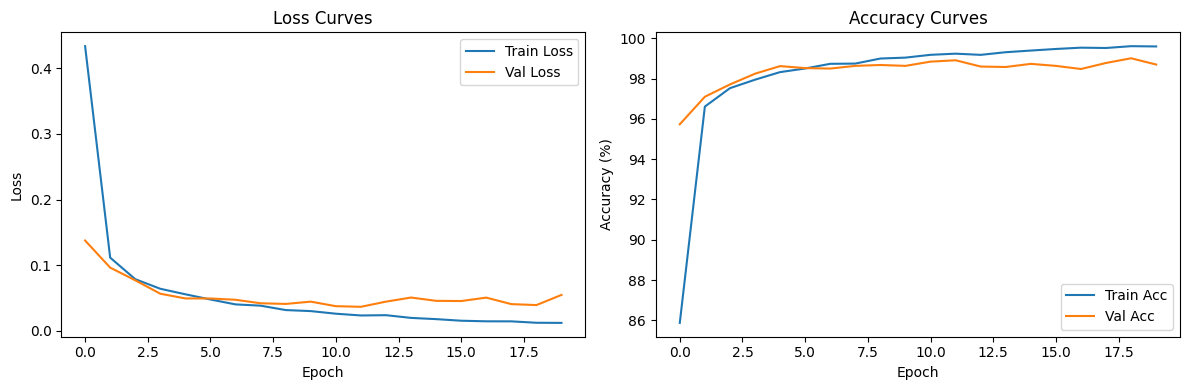


Test Accuracy: 98.86%


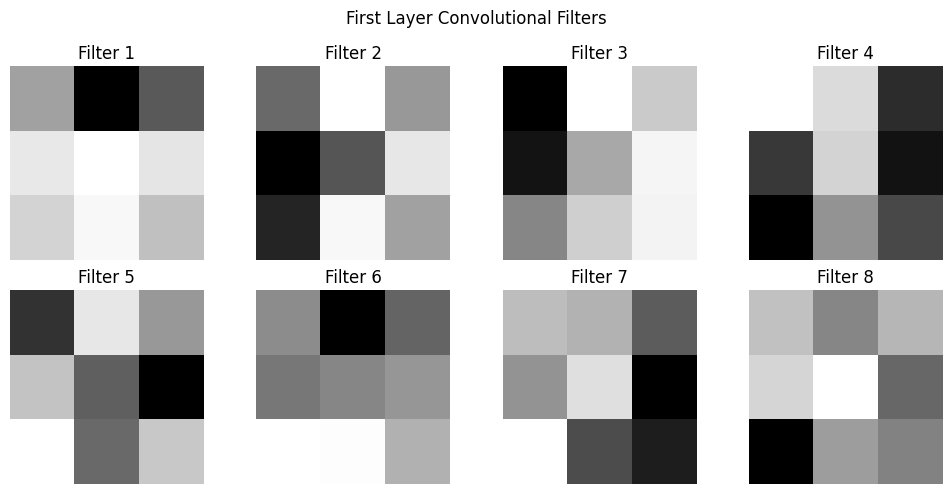

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CustomMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Check parameters
model = CustomMNISTCNN()
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,} / 50,000")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

# Split train into train/val
train_size = int(0.85 * len(train_set))
val_size = len(train_set) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_set, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

model = CustomMNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(20):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    # Val
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    train_losses.append(train_loss / train_total)
    val_losses.append(val_loss / val_total)
    train_accs.append(100 * train_correct / train_total)
    val_accs.append(100 * val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Acc={train_accs[-1]:.2f}%, Val Acc={val_accs[-1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss Curves')

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].set_title('Accuracy Curves')
plt.tight_layout()
plt.savefig('mnist_training_curves.png')
plt.show()

model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"\nTest Accuracy: {100 * test_correct / test_total:.2f}%")

filters = model.conv1.weight.data.cpu().numpy()  # (8, 1, 3, 3)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')
plt.suptitle('First Layer Convolutional Filters')
plt.tight_layout()
plt.savefig('mnist_filters.png')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_data = torch.load('cmnist/train_biased.pt')
biased_test = torch.load('cmnist/test_biased.pt')
unbiased_test = torch.load('cmnist/test_unbiased.pt')

# Unpack
X_train, y_train = train_data[0], train_data[1]
X_biased, y_biased = biased_test[0], biased_test[1]
X_unbiased, y_unbiased = unbiased_test[0], unbiased_test[1]

print(f"Train: {X_train.shape}, Biased: {X_biased.shape}, Unbiased: {X_unbiased.shape}")

# Create dataloaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
biased_loader = DataLoader(TensorDataset(X_biased, y_biased), batch_size=batch_size, shuffle=False)
unbiased_loader = DataLoader(TensorDataset(X_unbiased, y_unbiased), batch_size=batch_size, shuffle=False)

class CMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Check parameters
model = CMNISTCNN()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

model = CMNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Loss={total_loss/total:.4f}, Acc={100*correct/total:.2f}%")

def evaluate(loader, name):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    print(f"{name}: {acc:.2f}%")
    return acc

biased_acc = evaluate(biased_loader, "Biased Test")
unbiased_acc = evaluate(unbiased_loader, "Unbiased Test")
print(f"\nAccuracy Drop: {biased_acc - unbiased_acc:.2f}%")

Train: torch.Size([60000, 3, 28, 28]), Biased: torch.Size([10000, 3, 28, 28]), Unbiased: torch.Size([10000, 3, 28, 28])
Parameters: 29,162
Epoch 1: Loss=0.4129, Acc=88.79%
Epoch 2: Loss=0.1274, Acc=96.53%
Epoch 3: Loss=0.0916, Acc=97.36%
Epoch 4: Loss=0.0698, Acc=97.98%
Epoch 5: Loss=0.0540, Acc=98.43%
Epoch 6: Loss=0.0435, Acc=98.70%
Epoch 7: Loss=0.0364, Acc=98.95%
Epoch 8: Loss=0.0316, Acc=99.08%
Epoch 9: Loss=0.0294, Acc=99.08%
Epoch 10: Loss=0.0257, Acc=99.16%
Epoch 11: Loss=0.0217, Acc=99.37%
Epoch 12: Loss=0.0204, Acc=99.38%
Epoch 13: Loss=0.0181, Acc=99.41%
Epoch 14: Loss=0.0159, Acc=99.53%
Epoch 15: Loss=0.0150, Acc=99.51%
Epoch 16: Loss=0.0129, Acc=99.59%
Epoch 17: Loss=0.0124, Acc=99.57%
Epoch 18: Loss=0.0103, Acc=99.68%
Epoch 19: Loss=0.0098, Acc=99.68%
Epoch 20: Loss=0.0095, Acc=99.67%
Biased Test: 99.34%
Unbiased Test: 93.09%

Accuracy Drop: 6.25%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load STL-10
train_set = torchvision.datasets.STL10('./data', split='train', download=True, transform=transform)
test_set = torchvision.datasets.STL10('./data', split='test', download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Only train the new FC layer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Loss={train_loss/total:.4f}, Acc={100*correct/total:.2f}%")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

Epoch 1: Loss=1.3083, Acc=58.50%
Epoch 2: Loss=0.7533, Acc=76.22%
Epoch 3: Loss=0.6313, Acc=79.62%
Epoch 4: Loss=0.5867, Acc=80.96%
Epoch 5: Loss=0.5544, Acc=81.38%
Epoch 6: Loss=0.5201, Acc=82.20%
Epoch 7: Loss=0.4993, Acc=83.36%
Epoch 8: Loss=0.4840, Acc=84.20%
Epoch 9: Loss=0.4669, Acc=84.22%
Epoch 10: Loss=0.4613, Acc=84.20%

Test Accuracy: 78.84%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


 -_- CORRECT PREDICTIONS -_- 


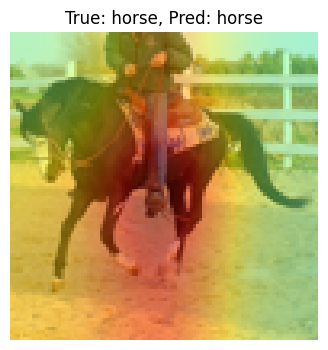

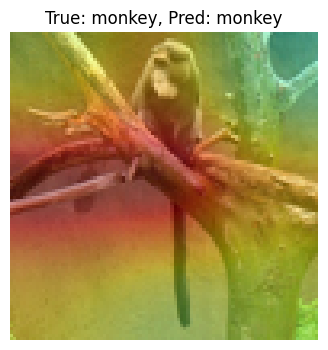

 -_- INCORRECT PREDICTIONS -_- 


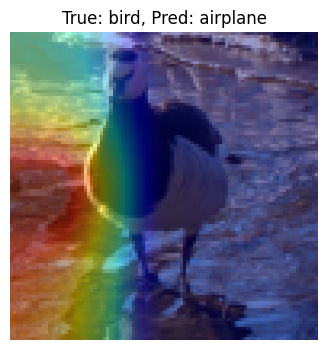

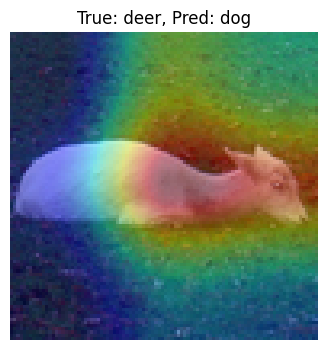

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, target_class):
        self.model.eval()
        input_image = input_image.unsqueeze(0).to(device)
        # Ensure input_image requires gradients for GradCAM
        input_image.requires_grad_(True)

        # Forward
        output = self.model(input_image)

        # Backward
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        # Compute weights
        pooled_grads = torch.mean(self.gradients, dim=[0, 2, 3])

        # Weighted combination of feature maps
        for i in range(self.activations.shape[1]):
            self.activations[0, i, :, :] *= pooled_grads[i]

        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)  # Normalize

        return heatmap.cpu().numpy()

def show_gradcam(image, heatmap, true_label, pred_label, save_name):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((96, 96))
    heatmap = plt.cm.jet(np.array(heatmap) / 255.0)[:, :, :3]

    image = image.permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())

    superimposed = heatmap * 0.4 + image * 0.6

    plt.figure(figsize=(4, 4))
    plt.imshow(superimposed)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis('off')
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()

# Initialize GradCAM on layer4 (final conv layer)
gradcam = GradCAM(model, model.layer4[-1])

# Get 2 correct and 2 incorrect predictions
correct_samples = []
incorrect_samples = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if len(correct_samples) < 2 and predicted[i] == labels[i]:
                correct_samples.append((images[i], labels[i].item(), predicted[i].item()))
            elif len(incorrect_samples) < 2 and predicted[i] != labels[i]:
                incorrect_samples.append((images[i], labels[i].item(), predicted[i].item()))

            if len(correct_samples) == 2 and len(incorrect_samples) == 2:
                break
        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

# Generate visualizations
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

print(" -_- CORRECT PREDICTIONS -_- ")
for idx, (img, true, pred) in enumerate(correct_samples):
    heatmap = gradcam.generate(img, pred)
    show_gradcam(img, heatmap, classes[true], classes[pred], f'gradcam_correct_{idx}.png')

print(" -_- INCORRECT PREDICTIONS -_- ")
for idx, (img, true, pred) in enumerate(incorrect_samples):
    heatmap = gradcam.generate(img, pred)
    show_gradcam(img, heatmap, classes[true], classes[pred], f'gradcam_incorrect_{idx}.png')